In [ ]:
# =====================================
# EXPERIMENT INFO
# =====================================

EXPERIMENT_NAME = "BEST_82"

NOTES = """
Normalization:
- Sample-wise normalization

Augmentation:
- Gaussian noise
- Temporal shift

Model:
- CNN-LSTM
- kernel_size = 3
- dropout = 0.5

Result:
- Accuracy ≈ ~82.6 Accuracy%
"""

print(EXPERIMENT_NAME)
print(NOTES)

BEST_81

Normalization:
- Sample-wise normalization

Augmentation:
- Gaussian noise
- Temporal shift

Model:
- CNN-LSTM
- kernel_size = 3
- dropout = 0.5

Result:
- Accuracy ≈ 81.25%



In [63]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical


In [64]:
X = np.load("../X_data.npy")
y = np.load("../y_user.npy")

print("Normalization öncesi:")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

X_normalized = []

for sample in X:

    sample_mean = np.mean(sample)
    sample_std = np.std(sample)

    sample = (
        sample - sample_mean
    ) / (sample_std + 1e-8)

    X_normalized.append(sample)

X = np.array(X_normalized)

print("Shape:", X.shape)

print("Mean:", np.mean(X))
print("Std:", np.std(X))
print("\nNormalization sonrası:")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

Normalization öncesi:
Min: -128.0
Max: 127.0
Mean: 0.105628476
Std: 21.704966
Shape: (720, 100, 64)
Mean: 7.8645014e-11
Std: 1.0000001

Normalization sonrası:
Min: -6.220304
Max: 6.105876
Mean: 7.8645014e-11
Std: 1.0000001


In [65]:
user_names = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya"
}

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
# Gaussian Noise
noise = np.random.normal(
    0,
    0.02,
    X_train.shape
)

X_noise = X_train + noise


# Temporal Shift
def temporal_shift(sample, shift=5):
    return np.roll(sample, shift, axis=0)

X_shifted = np.array([
    temporal_shift(
        x,
        shift=np.random.randint(-5,5)
    )
    for x in X_train
])


# Combine
X_train_final = np.concatenate([
    X_train,
    X_noise,
    X_shifted
], axis=0)

y_train_final = np.concatenate([
    y_train,
    y_train,
    y_train
], axis=0)

In [68]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(
    y_train_final,
    num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes
)

print(y_train_cat.shape)

(1728, 4)


In [69]:
model = Sequential([

    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        input_shape=(100,64)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
history = model.fit(
    X_train_final,
    y_train_cat,

    validation_data=(
        X_test,
        y_test_cat
    ),

    epochs=25,
    batch_size=16
)

Epoch 1/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2598 - loss: 1.4147 - val_accuracy: 0.3819 - val_loss: 1.3395
Epoch 2/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3964 - loss: 1.2745 - val_accuracy: 0.4514 - val_loss: 1.1168
Epoch 3/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5833 - loss: 1.0081 - val_accuracy: 0.4444 - val_loss: 1.2597
Epoch 4/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5943 - loss: 0.9679 - val_accuracy: 0.7083 - val_loss: 0.8436
Epoch 5/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6377 - loss: 0.9146 - val_accuracy: 0.6806 - val_loss: 0.8790
Epoch 6/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6615 - loss: 0.8488 - val_accuracy: 0.6319 - val_loss: 0.8486
Epoch 7/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5440 - loss: 1.1228 - val_accuracy: 0.6944 - val_loss: 0.9083
Epoch 8/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6759 - loss: 0.8445 - val_accu

In [71]:
loss, acc = model.evaluate(X_test, y_test_cat)

print("Final Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8264 - loss: 0.7407
Final Test Accuracy: 0.8263888955116272


In [72]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

print(classification_report(
    y_test,
    pred_classes,
    target_names=list(user_names.values())
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
              precision    recall  f1-score   support

      aleyna       0.91      0.81      0.85        36
       damla       0.81      0.81      0.81        36
       deniz       0.71      0.75      0.73        36
       derya       0.89      0.94      0.92        36

    accuracy                           0.83       144
   macro avg       0.83      0.83      0.83       144
weighted avg       0.83      0.83      0.83       144



In [73]:
import random

# Rastgele test örneği seç
idx = random.randint(0, len(X_test)-1)

test_sample = X_test[idx]
true_user_id = y_test[idx]

# Batch boyutu ekle
sample_input = np.expand_dims(test_sample, axis=0)

# Tahmin yap
prediction = model.predict(sample_input)

predicted_user_id = np.argmax(prediction)

# Mapping
id_to_user = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya"
}

print("------ CSI USER TEST DEMO ------")
print(f"Gerçek Kullanıcı : {id_to_user.get(true_user_id)}")
print(f"Tahmin Edilen    : {id_to_user.get(predicted_user_id)}")

confidence = np.max(prediction) * 100

print(f"Güven Skoru      : %{confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
------ CSI USER TEST DEMO ------
Gerçek Kullanıcı : deniz
Tahmin Edilen    : deniz
Güven Skoru      : %99.87


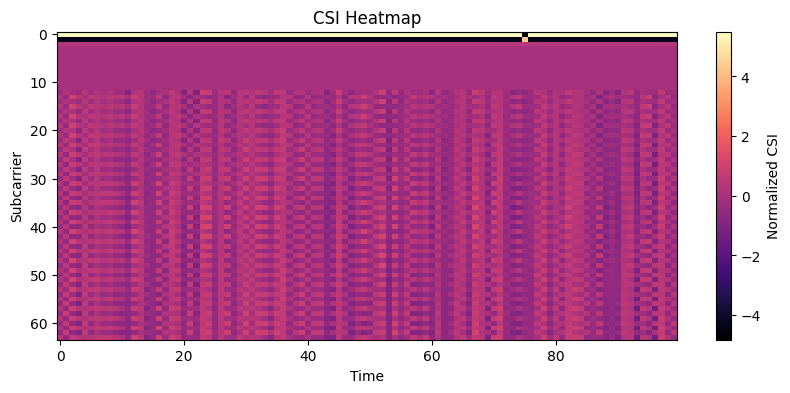

In [74]:
plt.figure(figsize=(10,4))

plt.imshow(test_sample.T,
           aspect='auto',
           cmap='magma')

plt.title("CSI Heatmap")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.colorbar(label="Normalized CSI")

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


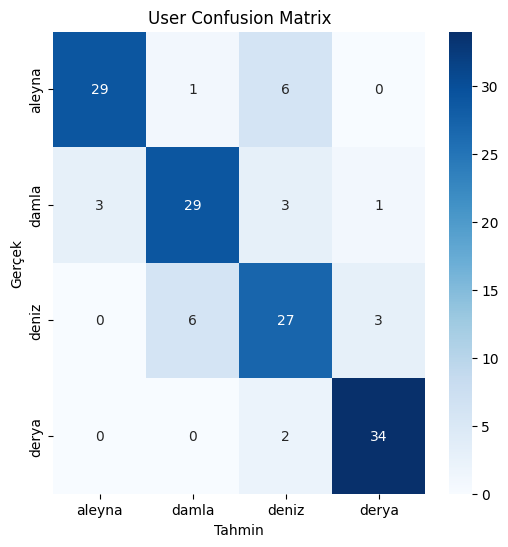

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(user_names.values()),
    yticklabels=list(user_names.values())
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("User Confusion Matrix")

plt.show()

In [76]:
model.save("../models/BEST_USER_MODEL_82.h5")